<a href="https://colab.research.google.com/github/wwvvlllttggiitt/ADII/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import os
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.inspection import permutation_importance

In [53]:
df = pd.read_csv('/content/Titanic.csv')
print("Loaded:", '/content/Titanic.csv')
display(df.head())

Loaded: /content/Titanic.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Приведение к стандартному виду

In [54]:
target = "Survived"
if target not in df.columns:
    raise ValueError(f"Не найден таргет '{target}'. Проверить колонки: {list(df.columns)}")

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

In [55]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))

Shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


EDA


[EDA] проверка пропусков


,0
Cabin,687
Age,177
Embarked,2


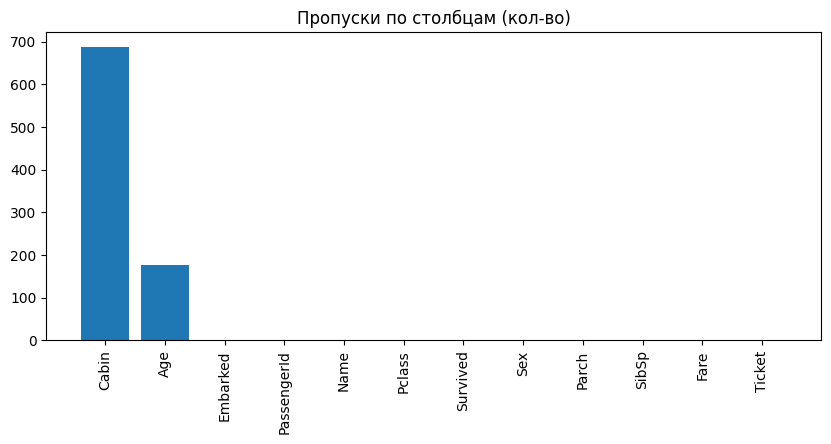

[EDA] Есть пропуски (обычно Age, Cabin, Embarked и др.). В дальнейшем применим импутацию и/или фичи типа 'Cabin_known'.


In [56]:
print("\n[EDA] проверка пропусков")
na_cnt = df.isna().sum().sort_values(ascending=False)
display(na_cnt[na_cnt > 0])

plt.figure(figsize=(10,4))
plt.title("Пропуски по столбцам (кол-во)")
plt.bar(na_cnt.index, na_cnt.values)
plt.xticks(rotation=90)
plt.show()

print("[EDA] Есть пропуски (обычно Age, Cabin, Embarked и др.). В дальнейшем применим импутацию и/или фичи типа 'Cabin_known'.")


[EDA] баланс классов по таргету Survived.


,count
Survived,
0,549
1,342


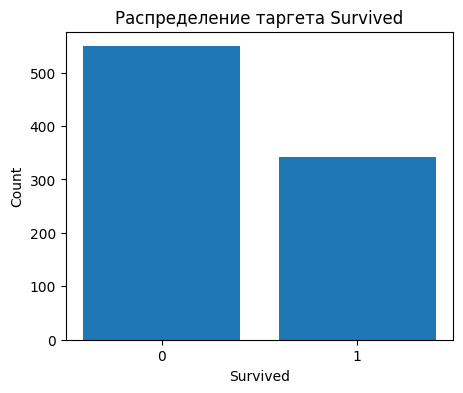

In [57]:
print("\n[EDA] баланс классов по таргету Survived.")
surv_counts = df[target].value_counts()
display(surv_counts)

plt.figure(figsize=(5,4))
plt.title("Распределение таргета Survived")
plt.bar(surv_counts.index.astype(str), surv_counts.values)
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()



[EDA] связь пола и выживаемости (гипотеза: женщины выживали чаще).


Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


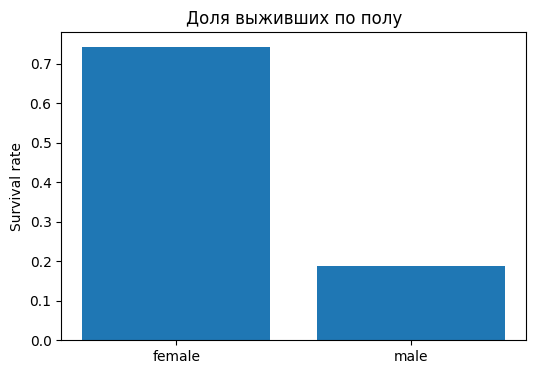

[EDA] пол — один из самых сильных факторов. Обычно survival rate (процент выживания) у женщин заметно выше.


In [58]:
if "Sex" in df.columns:
    print("\n[EDA] связь пола и выживаемости (гипотеза: женщины выживали чаще).")
    pivot_sex = pd.crosstab(df["Sex"], df[target], normalize="index")
    display(pivot_sex)

    plt.figure(figsize=(6,4))
    plt.title("Доля выживших по полу")
    plt.bar(pivot_sex.index, pivot_sex[1])
    plt.ylabel("Survival rate")
    plt.show()

    print("[EDA] пол — один из самых сильных факторов. Обычно survival rate (процент выживания) у женщин заметно выше.")


[EDA] класс каюты (Pclass) и выживаемость (гипотеза: 1 класс выживал чаще).


,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


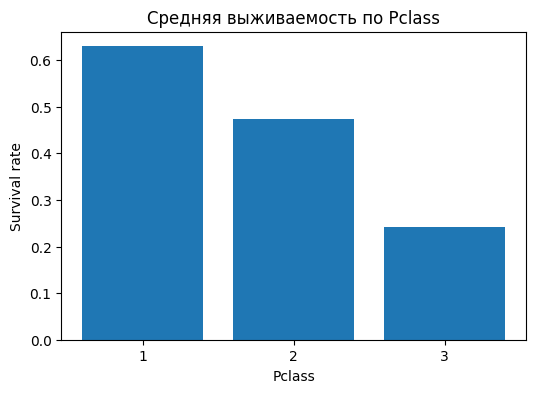

[EDA] Pclass сильно связан с шансами выжить (1 класс > 2 класс > 3 класс).


In [59]:
if "Pclass" in df.columns:
  print("\n[EDA] класс каюты (Pclass) и выживаемость (гипотеза: 1 класс выживал чаще).")
pivot_pclass = df.groupby("Pclass")[target].mean().sort_index()
display(pivot_pclass)

plt.figure(figsize=(6,4))
plt.title("Средняя выживаемость по Pclass")
plt.bar(pivot_pclass.index.astype(str), pivot_pclass.values)
plt.ylabel("Survival rate")
plt.xlabel("Pclass")
plt.show()

print("[EDA] Pclass сильно связан с шансами выжить (1 класс > 2 класс > 3 класс).")


[EDA] распределение Age и сравнение выживших/невыживших.


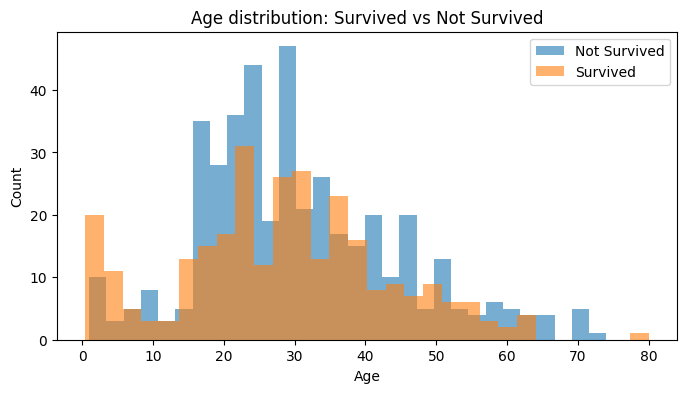

[EDA] Age (Возраст) влияет: дети выживали чаще, а очень пожилые — реже .


In [60]:
if "Age" in df.columns:
    print("\n[EDA] распределение Age и сравнение выживших/невыживших.")
    age_surv = df.loc[df[target] == 1, "Age"].dropna()
    age_dead = df.loc[df[target] == 0, "Age"].dropna()

    plt.figure(figsize=(8,4))
    plt.title("Age distribution: Survived vs Not Survived")
    plt.hist(age_dead, bins=30, alpha=0.6, label="Not Survived")
    plt.hist(age_surv, bins=30, alpha=0.6, label="Survived")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

    print("[EDA] Age (Возраст) влияет: дети выживали чаще, а очень пожилые — реже .")


[EDA] распределение Fare и связь с Survived (гипотеза: более дорогие билеты -> выше шанс выжить).


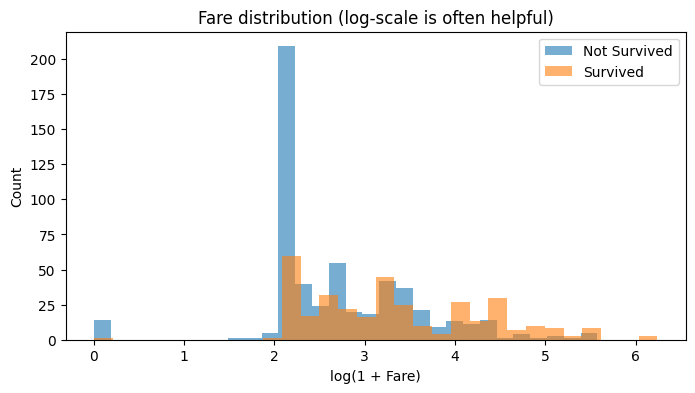

[EDA] Fare часто коррелирует с выживаемостью (богатые/дорогие билеты -> выше шанс).


In [61]:
if "Fare" in df.columns:
    print("\n[EDA] распределение Fare и связь с Survived (гипотеза: более дорогие билеты -> выше шанс выжить).")
    fare_surv = df.loc[df[target] == 1, "Fare"].dropna()
    fare_dead = df.loc[df[target] == 0, "Fare"].dropna()

    plt.figure(figsize=(8,4))
    plt.title("Fare distribution (log-scale is often helpful)")
    plt.hist(np.log1p(fare_dead), bins=30, alpha=0.6, label="Not Survived")
    plt.hist(np.log1p(fare_surv), bins=30, alpha=0.6, label="Survived")
    plt.xlabel("log(1 + Fare)")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

    print("[EDA] Fare часто коррелирует с выживаемостью (богатые/дорогие билеты -> выше шанс).")


[EDA] корреляция числовых признаков с таргетом (Pearson) и построение heatmap.


,Survived
Survived,1.000000
Fare,0.257307
Parch,0.081629
PassengerId,-0.005007
SibSp,-0.035322
Age,-0.077221
Pclass,-0.338481


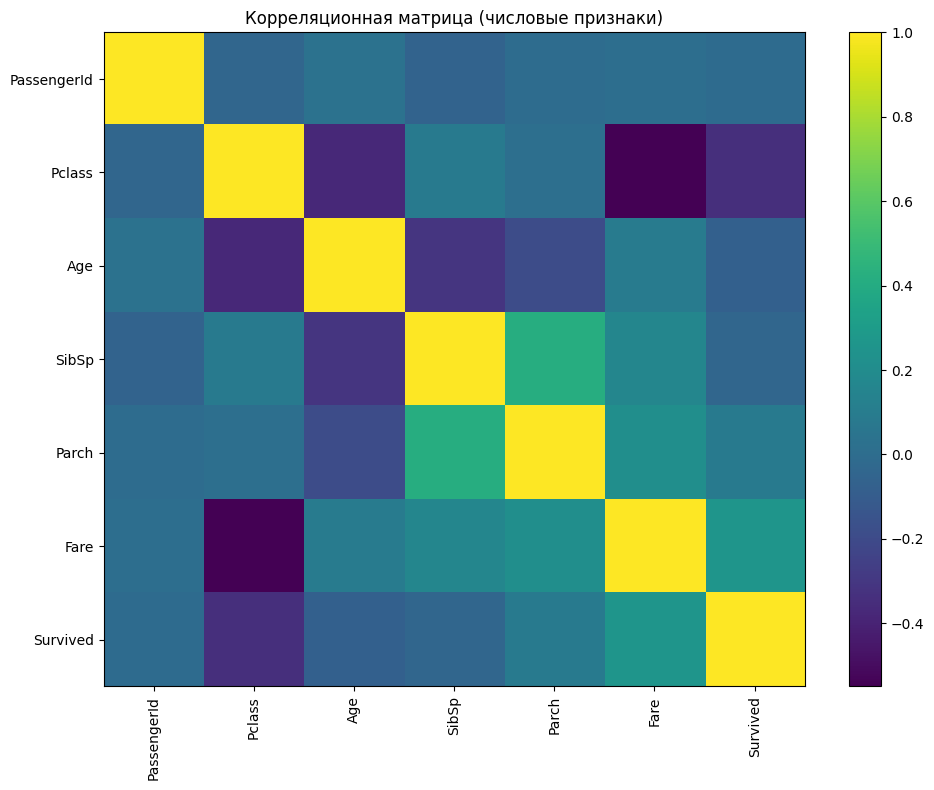

[EDA] признаки с заметной корреляцией с Survived (часто Fare, Pclass, SibSp/Parch и т.д.).


In [62]:
print("\n[EDA] корреляция числовых признаков с таргетом (Pearson) и построение heatmap.")
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != target]

corr_series = df[num_cols + [target]].corr(numeric_only=True)[target].sort_values(ascending=False)
display(corr_series)

# Heatmap корреляций числовых
corr_mat = df[num_cols + [target]].corr(numeric_only=True)
plt.figure(figsize=(10,8))
plt.title("Корреляционная матрица (числовые признаки)")
plt.imshow(corr_mat, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_mat.columns)), corr_mat.columns, rotation=90)
plt.yticks(range(len(corr_mat.index)), corr_mat.index)
plt.tight_layout()
plt.show()

print("[EDA] признаки с заметной корреляцией с Survived (часто Fare, Pclass, SibSp/Parch и т.д.).")

Feature-engineering

In [63]:
df_fe = df.copy()

def extract_title(name: str):
    if pd.isna(name):
        return "Unknown"
    m = re.search(r",\s*([^\.]+)\.", str(name))
    return m.group(1).strip() if m else "Unknown"

# Title из Name
if "Name" in df_fe.columns:
    df_fe["Title"] = df_fe["Name"].apply(extract_title)
    rare_titles = ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"]
    df_fe["Title"] = df_fe["Title"].replace(rare_titles, "Rare")
    df_fe["Title"] = df_fe["Title"].replace({"Mlle":"Miss","Ms":"Miss","Mme":"Mrs"})
# FamilySize, IsAlone
sib = df_fe["SibSp"] if "SibSp" in df_fe.columns else 0
par = df_fe["Parch"] if "Parch" in df_fe.columns else 0
df_fe["FamilySize"] = sib + par + 1
df_fe["IsAlone"] = (df_fe["FamilySize"] == 1).astype(int)
# Cabin known
if "Cabin" in df_fe.columns:
    df_fe["Cabin_known"] = df_fe["Cabin"].notna().astype(int)
# Ticket group size
if "Ticket" in df_fe.columns:
    ticket_counts = df_fe["Ticket"].value_counts()
    df_fe["TicketGroupSize"] = df_fe["Ticket"].map(ticket_counts)
# Age bins
if "Age" in df_fe.columns:
    df_fe["AgeGroup"] = pd.cut(
        df_fe["Age"],
        bins=[-1, 12, 18, 35, 60, 120],
        labels=["Child","Teen","Young","Adult","Senior"]
    )
# Fare log
if "Fare" in df_fe.columns:
    df_fe["FareLog"] = np.log1p(df_fe["Fare"])


print("\n[FE] созданы новые признаки (Title, FamilySize, IsAlone, Cabin_known, TicketGroupSize, AgeGroup, FareLog).")
print("[FE] проверка их корреляции числовых признаков с таргетом.")

new_num = [c for c in ["FamilySize","IsAlone","Cabin_known","TicketGroupSize","FareLog"] if c in df_fe.columns]
if len(new_num) > 0:
    new_corr = df_fe[new_num + [target]].corr(numeric_only=True)[target].sort_values(ascending=False)
    display(new_corr)

print("[FE] новые признаки часто улучшают качество (например Cabin_known, IsAlone, FareLog могут быть информативными).")


[FE] созданы новые признаки (Title, FamilySize, IsAlone, Cabin_known, TicketGroupSize, AgeGroup, FareLog).
[FE] проверка их корреляции числовых признаков с таргетом.


,Survived
Survived,1.000000
FareLog,0.329862
Cabin_known,0.316912
TicketGroupSize,0.038247
FamilySize,0.016639
IsAlone,-0.203367


[FE] новые признаки часто улучшают качество (например Cabin_known, IsAlone, FareLog могут быть информативными).


Препроцессоринг

In [64]:
y = df_fe[target]
X = df_fe.drop(columns=[target], errors="ignore")

X = X.drop(columns=["PassengerId"], errors="ignore")

num_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object","category"]).columns.tolist()

print("\nFeatures:")
print("Numeric:", num_features)
print("Categorical:", cat_features)

# препроцессор: импутация + scaling, импутация + onehot
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ],
    remainder="drop"
)


Features:
Numeric: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Cabin_known', 'TicketGroupSize', 'FareLog']
Categorical: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Title', 'AgeGroup']


Feature importances

In [65]:
print("\n[Model] простая модель (baseline): Logistic Regression")
baseline_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

baseline_model.fit(X_train, y_train)
pred = baseline_model.predict(X_test)
proba = baseline_model.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, pred)
f1 = f1_score(y_test, pred)
auc = roc_auc_score(y_test, proba)

print("Baseline metrics:")
print("Accuracy:", round(acc, 4))
print("F1:", round(f1, 4))
print("ROC-AUC:", round(auc, 4))

print("\n[Model] baseline дает точку отсчёта. Сравним деревья/бустинг/нейросеть.")


[Model] простая модель (baseline): Logistic Regression
Baseline metrics:
Accuracy: 0.8436
F1: 0.7971
ROC-AUC: 0.8713

[Model] baseline дает точку отсчёта. Сравним деревья/бустинг/нейросеть.


Random forest + permution importance

In [66]:

print("\n[FI] Feature Importances: RandomForest + permutation importance")

rf_for_fi = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    ))
])

rf_for_fi.fit(X_train, y_train)
rf_pred = rf_for_fi.predict(X_test)
rf_proba = rf_for_fi.predict_proba(X_test)[:,1]
print("RandomForest ROC-AUC:", round(roc_auc_score(y_test, rf_proba), 4))

perm = permutation_importance(
    rf_for_fi, X_test, y_test,
    n_repeats=10, random_state=42, scoring="roc_auc"
)


[FI] Feature Importances: RandomForest + permutation importance
RandomForest ROC-AUC: 0.8447


список фичей

,0
Sex,0.073307
Title,0.025856
Pclass,0.008656
TicketGroupSize,0.001825
Embarked,0.001311
Parch,0.001041
SibSp,0.000823
AgeGroup,0.000323
Name,0.000000
Cabin,-0.000224


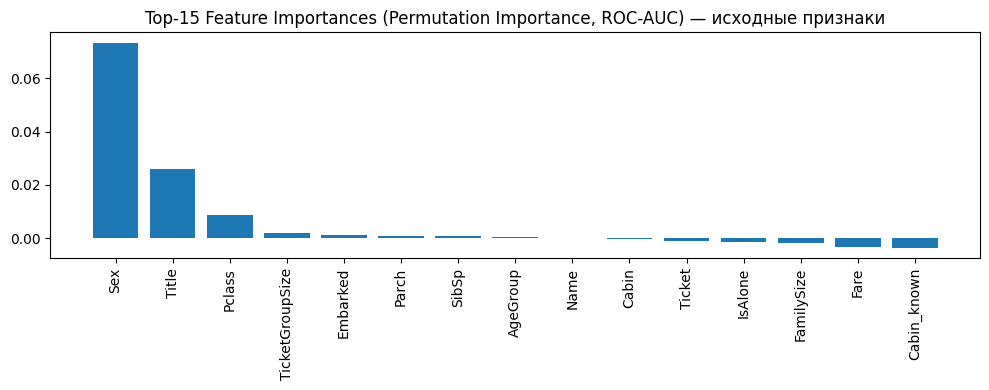

[FI] интерпретация по исходным признакам (до one-hot).


In [67]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

perm = permutation_importance(
    rf_for_fi, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

fi = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

display(fi.head(15))

plt.figure(figsize=(10,4))
plt.title("Top-15 Feature Importances (Permutation Importance, ROC-AUC) — исходные признаки")
plt.bar(fi.head(15).index.astype(str), fi.head(15).values)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("[FI] интерпретация по исходным признакам (до one-hot).")


Эксперименты с моделями

In [68]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])


preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ],
    remainder="drop",
    sparse_threshold=0
)

Лучшая модель

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear (LogReg)": LogisticRegression(max_iter=2000),
    "Tree (DecisionTree)": DecisionTreeClassifier(random_state=42),
    "Trees (RandomForest)": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Boosting (HistGB)": HistGradientBoostingClassifier(random_state=42),
    "NeuralNet (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=400, random_state=42)
}

results = []
for name, est in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", est)])
    scores_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    results.append({
        "Model": name,
        "ROC_AUC_mean": scores_auc.mean(),
        "ROC_AUC_std": scores_auc.std()
    })

results_df = pd.DataFrame(results).sort_values("ROC_AUC_mean", ascending=False)
results_df

,Model,ROC_AUC_mean,ROC_AUC_std
4,NeuralNet (MLP),0.897805,0.017084
2,Trees (RandomForest),0.888428,0.021972
3,Boosting (HistGB),0.888243,0.013520
0,Linear (LogReg),0.884912,0.019534
1,Tree (DecisionTree),0.820477,0.023238



Best model by CV ROC-AUC: NeuralNet (MLP)

[CV] Кросс-валидация для лучшей модели на всей выборке. Метрика ROC-AUC.
ROC-AUC scores: [0.9185112  0.87647059 0.86691176 0.8802139  0.91477197]
ROC-AUC mean: 0.8914
ROC-AUC std: 0.0211

[CV] низкое std = стабильная модель, высокий mean = хорошее обобщение.

Final hold-out metrics (test split):
Accuracy: 0.7933
F1: 0.7413
ROC-AUC: 0.8578

Confusion Matrix:
 [[89 21]
 [16 53]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.81      0.83       110
           1       0.72      0.77      0.74        69

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.78       179
weighted avg       0.80      0.79      0.79       179



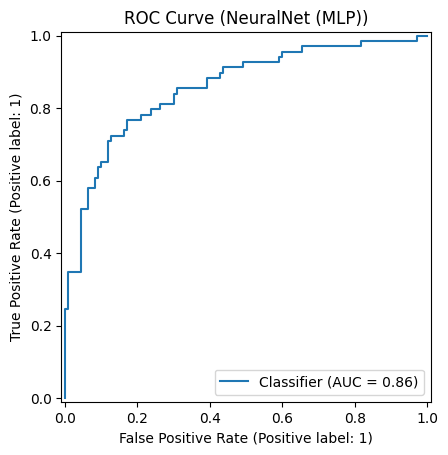

In [70]:
best_row = results_df.iloc[0]
best_model_name = best_row["Model"]
print("\nBest model by CV ROC-AUC:", best_model_name)

best_estimator = models[best_model_name]
best_pipe = Pipeline(steps=[("preprocess", preprocess), ("model", best_estimator)])

# 5 кросс валидация
print("\n[CV] Кросс-валидация для лучшей модели на всей выборке. Метрика ROC-AUC.")
scores_auc_full = cross_val_score(best_pipe, X, y, cv=cv, scoring="roc_auc")
print("ROC-AUC scores:", scores_auc_full)
print("ROC-AUC mean:", round(scores_auc_full.mean(), 4))
print("ROC-AUC std:", round(scores_auc_full.std(), 4))

print("\n[CV] низкое std = стабильная модель, высокий mean = хорошее обобщение.")

best_pipe.fit(X_train, y_train)
final_pred = best_pipe.predict(X_test)

if hasattr(best_pipe.named_steps["model"], "predict_proba"):
    final_proba = best_pipe.predict_proba(X_test)[:,1]
    final_auc = roc_auc_score(y_test, final_proba)
else:
    final_auc = np.nan

final_acc = accuracy_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)

print("\nFinal hold-out metrics (test split):")
print("Accuracy:", round(final_acc, 4))
print("F1:", round(final_f1, 4))
print("ROC-AUC:", round(final_auc, 4) if not np.isnan(final_auc) else "N/A")

cm = confusion_matrix(y_test, final_pred)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, final_pred))

if not np.isnan(final_auc):
    RocCurveDisplay.from_predictions(y_test, final_proba)
    plt.title(f"ROC Curve ({best_model_name})")
    plt.show()